In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.ticker as mticker

In [48]:
# pd.set_option('display.max_rows', None)

In [2]:
def verifica_nulos(df):
    total_linhas = len(df)
 
    resumo = pd.DataFrame({
        "Tipo"         : df.dtypes,
        "Nulos"        : df.isnull().sum(),
        "Percentual(%)": (df.isnull().sum() / total_linhas * 100).round(2),
        "Preenchidos"  : df.notnull().sum(),
    }).sort_values("Percentual(%)", ascending=False)
 
    colunas_com_nulo = resumo[resumo["Nulos"] > 0]
 
    print(f"\n  Total de colunas com nulos: {len(colunas_com_nulo)} de {df.shape[1]}")
    print(f"  Total de células nulas    : {df.isnull().sum().sum():,}")
    print(f"\n  {'Coluna':<30} {'Nulos':>10} {'Percentual':>12}")
    print(f"  {'-'*54}")
    for col, row in colunas_com_nulo.iterrows():
        print(f"  {col:<30} {int(row['Nulos']):>10,} {row['Percentual(%)']:>11.2f}%")

-----------------------------------------------------------------------------------------------------------

# Microdados ENEM 2023 - Inep
- MICRODADOS_ENEM_2023.CSV

In [19]:
# Carregando arquivo

COLUNAS_ENEM_2023 = ['NU_ANO','TP_SEXO', 'TP_COR_RACA', 'TP_ESCOLA', 'IN_TREINEIRO', 'CO_MUNICIPIO_PROVA', 'TP_PRESENCA_CN', 
                    'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT','NU_NOTA_CN', 'NU_NOTA_CH','NU_NOTA_LC',
                    'NU_NOTA_MT','NU_NOTA_REDACAO', 'TP_STATUS_REDACAO', 'Q005', 'Q006']

# Q005: Quantidade de moradores na residência.
# Q006: Renda familiar total.

df_enem2023 = pd.read_csv('MICRODADOS_ENEM_2023.csv', sep=';', encoding='latin-1', usecols=COLUNAS_ENEM_2023)

# Seleciona apenas os presentes no dia das provas
df_enem2023 = df_enem2023[(df_enem2023['TP_PRESENCA_CN'] == 1) & 
                          (df_enem2023['TP_PRESENCA_CH'] == 1) & 
                          (df_enem2023['TP_PRESENCA_LC'] == 1) & 
                          (df_enem2023['TP_PRESENCA_MT'] == 1)]

df_enem2023.drop('TP_PRESENCA_CN', axis=1, inplace=True)
df_enem2023.drop('TP_PRESENCA_CH', axis=1, inplace=True)
df_enem2023.drop('TP_PRESENCA_LC', axis=1, inplace=True)
df_enem2023.drop('TP_PRESENCA_MT', axis=1, inplace=True)
df_enem2023.drop('TP_STATUS_REDACAO', axis=1, inplace=True)


In [14]:
df_enem2023

,NU_ANO,TP_SEXO,TP_COR_RACA,TP_ESCOLA,IN_TREINEIRO,CO_MUNICIPIO_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q005,Q006
2,2023,F,1,1,0,4305108,1,1,1,1,502.0,498.9,475.6,363.2,1.0,700.0,5,C
3,2023,F,3,2,0,2304400,1,1,1,1,459.0,508.5,507.2,466.7,1.0,880.0,5,C
4,2023,F,3,2,0,2311306,1,1,1,1,402.5,379.2,446.9,338.3,1.0,560.0,4,B
9,2023,M,1,1,0,3505906,1,1,1,1,564.7,630.3,610.4,680.2,1.0,600.0,2,F
10,2023,M,3,1,0,2408102,1,1,1,1,644.9,620.2,626.9,736.3,1.0,860.0,4,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3933946,2023,F,1,1,0,4314902,1,1,1,1,568.6,605.2,598.2,496.8,1.0,500.0,3,D
3933948,2023,M,1,2,0,4318705,1,1,1,1,476.2,542.9,545.2,530.5,1.0,600.0,4,F
3933950,2023,M,1,1,0,4303103,1,1,1,1,566.2,605.6,613.7,547.3,1.0,540.0,5,F
3933951,2023,F,1,1,1,3550308,1,1,1,1,377.2,535.6,610.6,644.4,1.0,640.0,4,F


In [15]:
duplicatas = df_enem2023.duplicated().sum()
print(duplicatas)

0


In [20]:
# Adicionando colunas de região e UF

REGIOES = {"1": "Norte", "2": "Nordeste", "3": "Sudeste", "4": "Sul", "5": "Centro-Oeste"}

UFS = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA", "16": "AP", "17": "TO",
    "21": "MA", "22": "PI", "23": "CE", "24": "RN", "25": "PB", "26": "PE",
    "27": "AL", "28": "SE", "29": "BA",
    "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS",
    "50": "MS", "51": "MT", "52": "GO", "53": "DF"
}

df_enem2023["NO_REGIAO"] = df_enem2023["CO_MUNICIPIO_PROVA"].astype(str).str[0].map(REGIOES)
df_enem2023["SG_UF"]     = df_enem2023["CO_MUNICIPIO_PROVA"].astype(str).str[:2].map(UFS)

df_enem2023.drop('CO_MUNICIPIO_PROVA', axis=1, inplace=True)
df_enem2023

,NU_ANO,TP_SEXO,TP_COR_RACA,TP_ESCOLA,IN_TREINEIRO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q005,Q006,NO_REGIAO,SG_UF
2,2023,F,1,1,0,502.0,498.9,475.6,363.2,700.0,5,C,Sul,RS
3,2023,F,3,2,0,459.0,508.5,507.2,466.7,880.0,5,C,Nordeste,CE
4,2023,F,3,2,0,402.5,379.2,446.9,338.3,560.0,4,B,Nordeste,CE
9,2023,M,1,1,0,564.7,630.3,610.4,680.2,600.0,2,F,Sudeste,SP
10,2023,M,3,1,0,644.9,620.2,626.9,736.3,860.0,4,B,Nordeste,RN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3933946,2023,F,1,1,0,568.6,605.2,598.2,496.8,500.0,3,D,Sul,RS
3933948,2023,M,1,2,0,476.2,542.9,545.2,530.5,600.0,4,F,Sul,RS
3933950,2023,M,1,1,0,566.2,605.6,613.7,547.3,540.0,5,F,Sul,RS
3933951,2023,F,1,1,1,377.2,535.6,610.6,644.4,640.0,4,F,Sudeste,SP


In [21]:
colunas_notas = ["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO"]

df_enem2023["NOTA_GERAL"] = df_enem2023[colunas_notas].mean(axis=1)
df_enem2023

,NU_ANO,TP_SEXO,TP_COR_RACA,TP_ESCOLA,IN_TREINEIRO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q005,Q006,NO_REGIAO,SG_UF,NOTA_GERAL
2,2023,F,1,1,0,502.0,498.9,475.6,363.2,700.0,5,C,Sul,RS,507.94
3,2023,F,3,2,0,459.0,508.5,507.2,466.7,880.0,5,C,Nordeste,CE,564.28
4,2023,F,3,2,0,402.5,379.2,446.9,338.3,560.0,4,B,Nordeste,CE,425.38
9,2023,M,1,1,0,564.7,630.3,610.4,680.2,600.0,2,F,Sudeste,SP,617.12
10,2023,M,3,1,0,644.9,620.2,626.9,736.3,860.0,4,B,Nordeste,RN,697.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3933946,2023,F,1,1,0,568.6,605.2,598.2,496.8,500.0,3,D,Sul,RS,553.76
3933948,2023,M,1,2,0,476.2,542.9,545.2,530.5,600.0,4,F,Sul,RS,538.96
3933950,2023,M,1,1,0,566.2,605.6,613.7,547.3,540.0,5,F,Sul,RS,574.56
3933951,2023,F,1,1,1,377.2,535.6,610.6,644.4,640.0,4,F,Sudeste,SP,561.56


In [22]:
# Valores nulos ENEM 2023

verifica_nulos(df_enem2023)


  Total de colunas com nulos: 0 de 15
  Total de células nulas    : 0

  Coluna                              Nulos   Percentual
  ------------------------------------------------------


In [ ]:
df_enem2023.to_csv('ENEM_Tratado_2023.csv', index=False)

In [23]:
df_enem2023

,NU_ANO,TP_SEXO,TP_COR_RACA,TP_ESCOLA,IN_TREINEIRO,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO,Q005,Q006,NO_REGIAO,SG_UF,NOTA_GERAL
2,2023,F,1,1,0,502.0,498.9,475.6,363.2,700.0,5,C,Sul,RS,507.94
3,2023,F,3,2,0,459.0,508.5,507.2,466.7,880.0,5,C,Nordeste,CE,564.28
4,2023,F,3,2,0,402.5,379.2,446.9,338.3,560.0,4,B,Nordeste,CE,425.38
9,2023,M,1,1,0,564.7,630.3,610.4,680.2,600.0,2,F,Sudeste,SP,617.12
10,2023,M,3,1,0,644.9,620.2,626.9,736.3,860.0,4,B,Nordeste,RN,697.66
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3933946,2023,F,1,1,0,568.6,605.2,598.2,496.8,500.0,3,D,Sul,RS,553.76
3933948,2023,M,1,2,0,476.2,542.9,545.2,530.5,600.0,4,F,Sul,RS,538.96
3933950,2023,M,1,1,0,566.2,605.6,613.7,547.3,540.0,5,F,Sul,RS,574.56
3933951,2023,F,1,1,1,377.2,535.6,610.6,644.4,640.0,4,F,Sudeste,SP,561.56


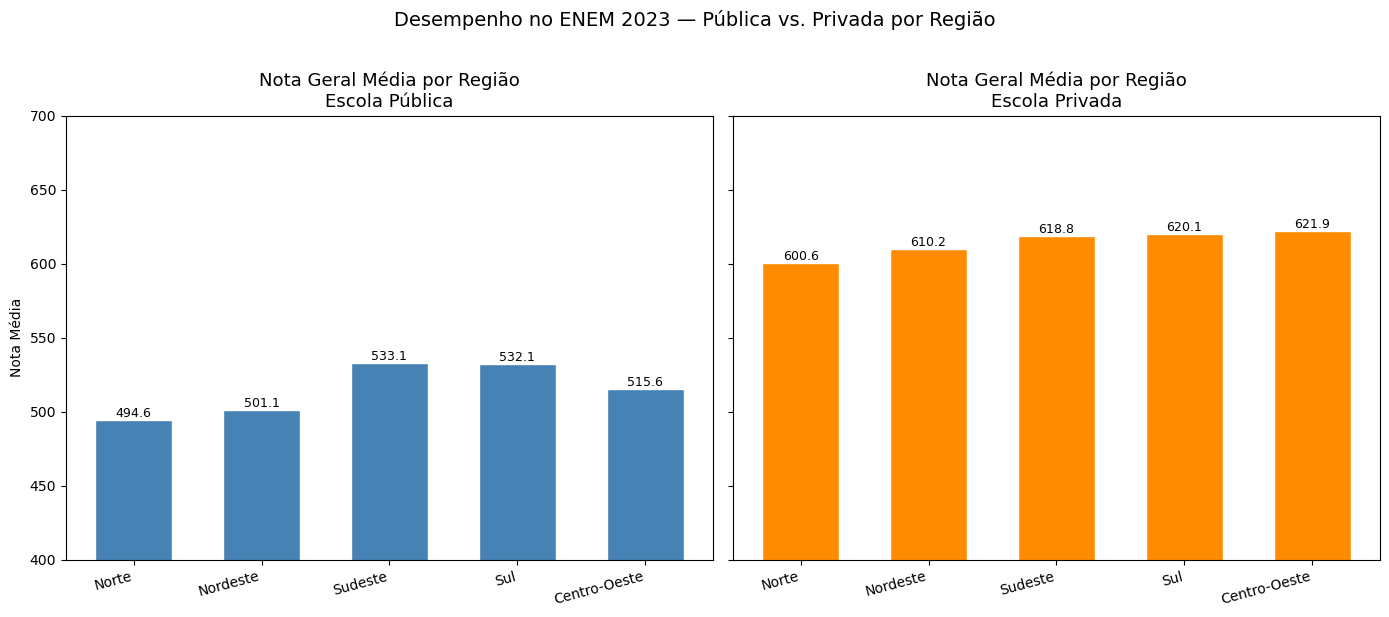

In [ ]:
# TP_ESCOLA: 2 = Pública, 3 = Privada
publica  = df_enem2023[df_enem2023["TP_ESCOLA"] == 2]
privada  = df_enem2023[df_enem2023["TP_ESCOLA"] == 3]

media_publica = publica.groupby("NO_REGIAO")["NOTA_GERAL"].mean().reindex(REGIOES.values())
media_privada = privada.groupby("NO_REGIAO")["NOTA_GERAL"].mean().reindex(REGIOES.values())

regioes = list(REGIOES.values())
x = np.arange(len(regioes))

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)

# Histograma 1 — Escola Pública
axes[0].bar(x, media_publica, color="steelblue", edgecolor="white", width=0.6)
axes[0].set_title("Nota Geral Média por Região\nEscola Pública", fontsize=13)
axes[0].set_xticks(x)
axes[0].set_xticklabels(regioes, rotation=15, ha="right")
axes[0].set_ylabel("Nota Média")
axes[0].set_ylim(400, 700)
for i, v in enumerate(media_publica):
    axes[0].text(i, v + 2, f"{v:.1f}", ha="center", fontsize=9)

# Histograma 2 — Escola Privada
axes[1].bar(x, media_privada, color="darkorange", edgecolor="white", width=0.6)
axes[1].set_title("Nota Geral Média por Região\nEscola Privada", fontsize=13)
axes[1].set_xticks(x)
axes[1].set_xticklabels(regioes, rotation=15, ha="right")
for i, v in enumerate(media_privada):
    axes[1].text(i, v + 2, f"{v:.1f}", ha="center", fontsize=9)

plt.suptitle("Desempenho no ENEM 2023 — Pública vs. Privada por Região", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("histograma_regiao_escola.png", dpi=120, bbox_inches="tight")
plt.show()

In [27]:
RENDA_LABEL = {
    "A": 0.0,
    "B": 1320.0,
    "C": 1650.0,
    "D": 2310.0,
    "E": 2970.0,
    "F": 3630.0,
    "G": 4620.0,
    "H": 5940.0,
    "I": 7260.0,
    "J": 8580.0,
    "K": 9900.0,
    "L": 11220.0,
    "M": 12540.0,
    "N": 14520.0,
    "O": 17820.0,
    "P": 23100.0,
    "Q": 26400.0
}

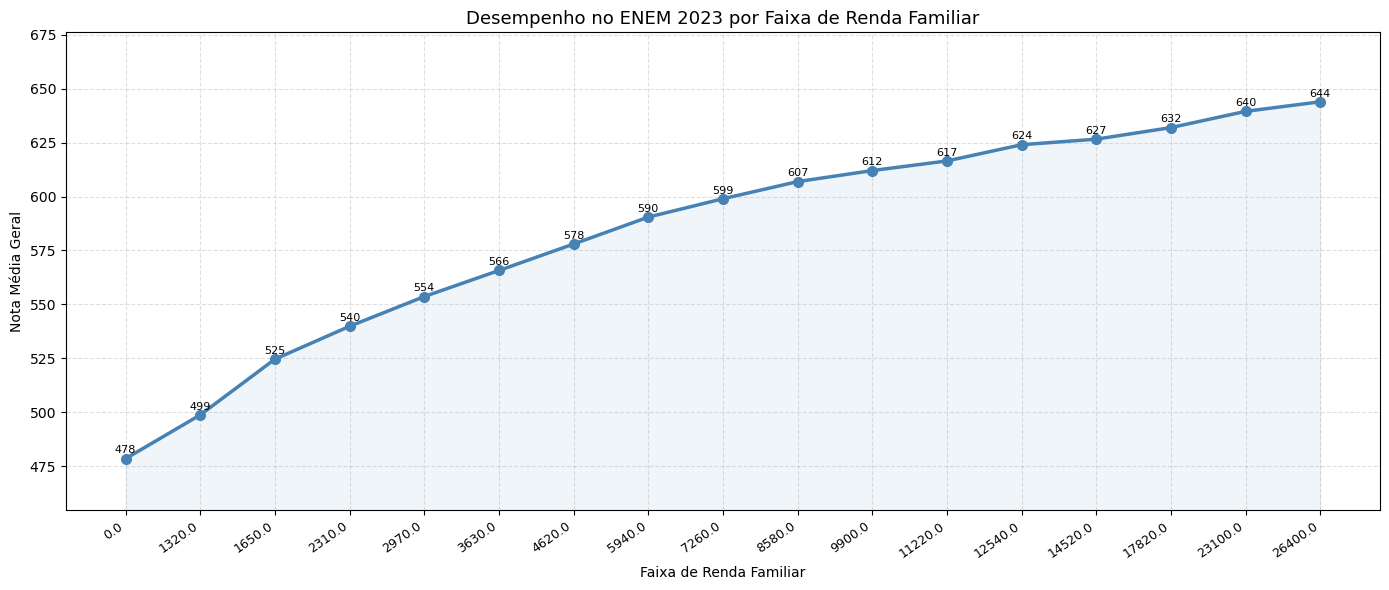

In [29]:
# Nota média por faixa de renda (mantendo ordem A→Q)
ordem = list(RENDA_LABEL.keys())
media_renda = (
    df_enem2023.groupby("Q006")["NOTA_GERAL"]
    .mean()
    .reindex(ordem)
)

labels = [RENDA_LABEL[k] for k in ordem]

# Gradiente de cor por nível de renda
cmap   = plt.cm.RdYlGn
cores  = [cmap(i / (len(ordem) - 1)) for i in range(len(ordem))]

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(range(len(ordem)), media_renda, color="steelblue",
        linewidth=2.5, marker="o", markersize=7, zorder=3)

# Rótulos de valor acima de cada ponto
for i, valor in enumerate(media_renda):
    if not np.isnan(valor):
        ax.text(i, valor + 1.5, f"{valor:.0f}",
                ha="center", va="bottom", fontsize=8)

ax.set_xticks(range(len(ordem)))
ax.set_xticklabels(labels, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Nota Média Geral")
ax.set_xlabel("Faixa de Renda Familiar")
ax.set_title("Desempenho no ENEM 2023 por Faixa de Renda Familiar", fontsize=13)
ax.set_ylim(media_renda.min() * 0.95, media_renda.max() * 1.05)
ax.grid(linestyle="--", alpha=0.4)
ax.fill_between(range(len(ordem)), media_renda,
                media_renda.min() * 0.95, alpha=0.08, color="steelblue")

plt.tight_layout()
plt.savefig("desempenho_por_renda_linha.png", dpi=120, bbox_inches="tight")
plt.show()

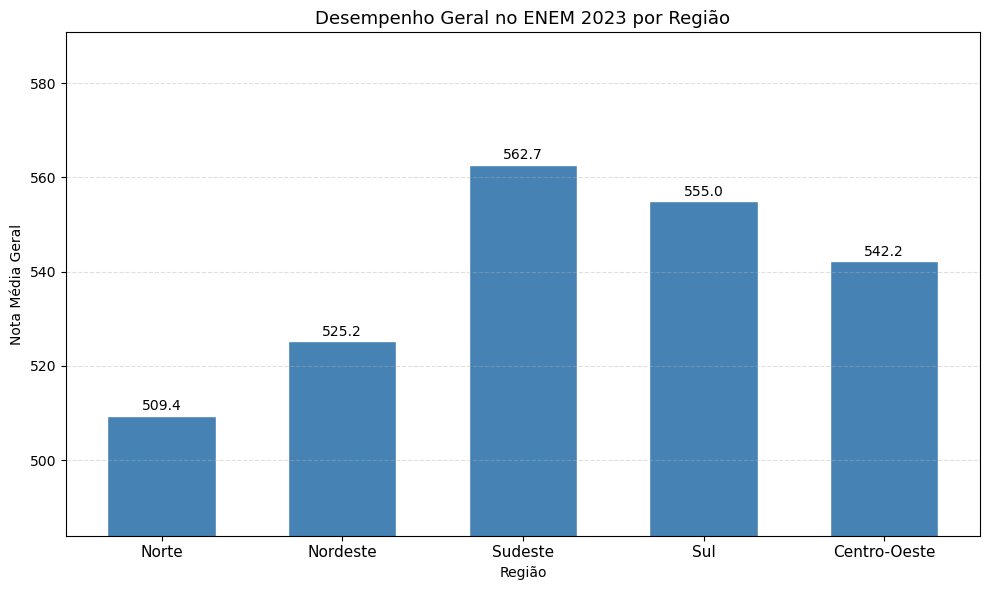

In [30]:
media_regiao = df_enem2023.groupby("NO_REGIAO")["NOTA_GERAL"].mean().reindex(REGIOES.values())

fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(range(len(regioes)), media_regiao,
              color="steelblue", edgecolor="white", width=0.6)

for bar, valor in zip(bars, media_regiao):
    ax.text(bar.get_x() + bar.get_width() / 2, valor + 0.5,
            f"{valor:.1f}", ha="center", va="bottom", fontsize=10)

ax.set_xticks(range(len(regioes)))
ax.set_xticklabels(regioes, fontsize=11)
ax.set_ylabel("Nota Média Geral")
ax.set_xlabel("Região")
ax.set_title("Desempenho Geral no ENEM 2023 por Região", fontsize=13)
ax.set_ylim(media_regiao.min() * 0.95, media_regiao.max() * 1.05)
ax.grid(axis="y", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("desempenho_por_regiao.png", dpi=120, bbox_inches="tight")
plt.show()

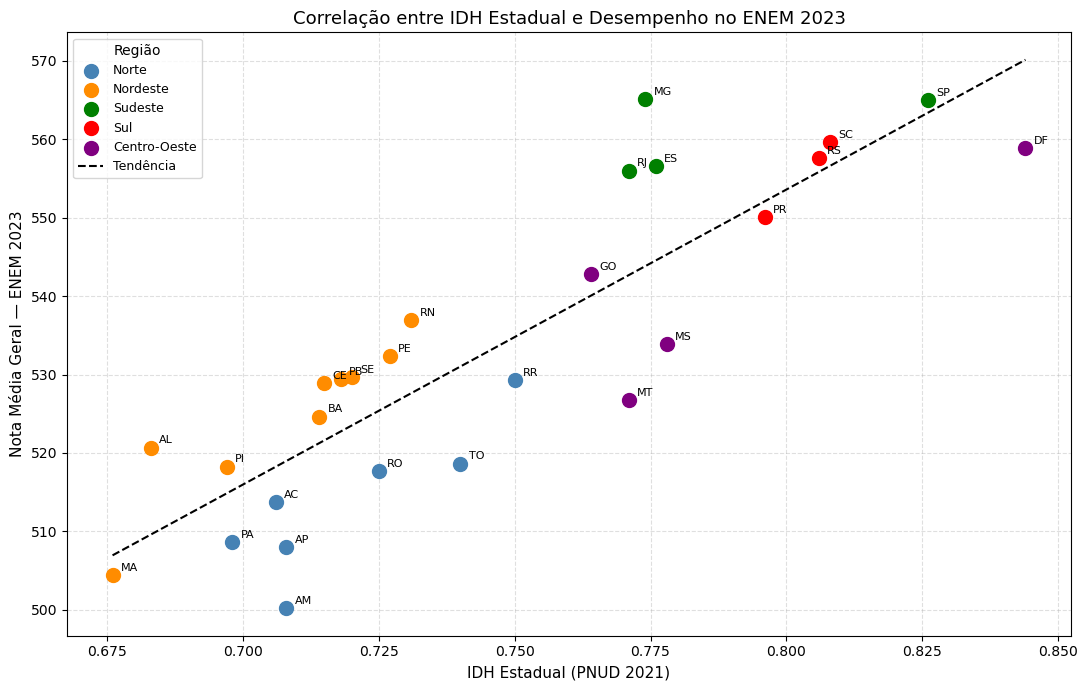

In [37]:
IDH_UF = {
    "RO": 0.725, "AC": 0.706, "AM": 0.708, "RR": 0.750, "PA": 0.698,
    "AP": 0.708, "TO": 0.740, "MA": 0.676, "PI": 0.697, "CE": 0.715,
    "RN": 0.731, "PB": 0.718, "PE": 0.727, "AL": 0.683, "SE": 0.720,
    "BA": 0.714, "MG": 0.774, "ES": 0.776, "RJ": 0.771, "SP": 0.826,
    "PR": 0.796, "SC": 0.808, "RS": 0.806, "MS": 0.778, "MT": 0.771,
    "GO": 0.764, "DF": 0.844
}

CORES_REGIAO = {
    "Norte":        "steelblue",
    "Nordeste":     "darkorange",
    "Sudeste":      "green",
    "Sul":          "red",
    "Centro-Oeste": "purple"
}

UF_REGIAO = {
    "RO": "Norte",   "AC": "Norte",   "AM": "Norte",  "RR": "Norte",
    "PA": "Norte",   "AP": "Norte",   "TO": "Norte",
    "MA": "Nordeste","PI": "Nordeste", "CE": "Nordeste","RN": "Nordeste",
    "PB": "Nordeste","PE": "Nordeste", "AL": "Nordeste","SE": "Nordeste",
    "BA": "Nordeste",
    "MG": "Sudeste", "ES": "Sudeste", "RJ": "Sudeste", "SP": "Sudeste",
    "PR": "Sul",     "SC": "Sul",     "RS": "Sul",
    "MS": "Centro-Oeste","MT": "Centro-Oeste",
    "GO": "Centro-Oeste","DF": "Centro-Oeste"
}

# Nota média por UF
media_uf = df_enem2023.groupby("SG_UF")["NOTA_GERAL"].mean()

# Alinhar UFs presentes em ambos
ufs = [uf for uf in IDH_UF if uf in media_uf.index]
idh_uf     = [IDH_UF[uf] for uf in ufs]
notas_uf   = [media_uf[uf] for uf in ufs]
cores_uf   = [CORES_REGIAO[UF_REGIAO[uf]] for uf in ufs]
regioes_uf = [UF_REGIAO[uf] for uf in ufs]

fig, ax = plt.subplots(figsize=(11, 7))

# Plotar pontos por região (para legenda agrupada)
for regiao, cor in CORES_REGIAO.items():
    idx = [i for i, r in enumerate(regioes_uf) if r == regiao]
    ax.scatter(
        [idh_uf[i] for i in idx],
        [notas_uf[i] for i in idx],
        color=cor, s=100, zorder=3, label=regiao
    )

# Rótulo de cada estado
for i, uf in enumerate(ufs):
    ax.annotate(uf, (idh_uf[i], notas_uf[i]),
                textcoords="offset points", xytext=(6, 3), fontsize=8)

# Linha de tendência geral
z = np.polyfit(idh_uf, notas_uf, 1)
p = np.poly1d(z)
x_line = np.linspace(min(idh_uf), max(idh_uf), 100)
ax.plot(x_line, p(x_line), color="black",
        linestyle="--", linewidth=1.5, label="Tendência", zorder=2)

ax.set_xlabel("IDH Estadual (PNUD 2021)", fontsize=11)
ax.set_ylabel("Nota Média Geral — ENEM 2023", fontsize=11)
ax.set_title("Correlação entre IDH Estadual e Desempenho no ENEM 2023", fontsize=13)
ax.legend(title="Região", fontsize=9)
ax.grid(linestyle="--", alpha=0.4)

plt.tight_layout()
plt.savefig("correlacao_idh_nota_uf.png", dpi=120, bbox_inches="tight")
plt.show()

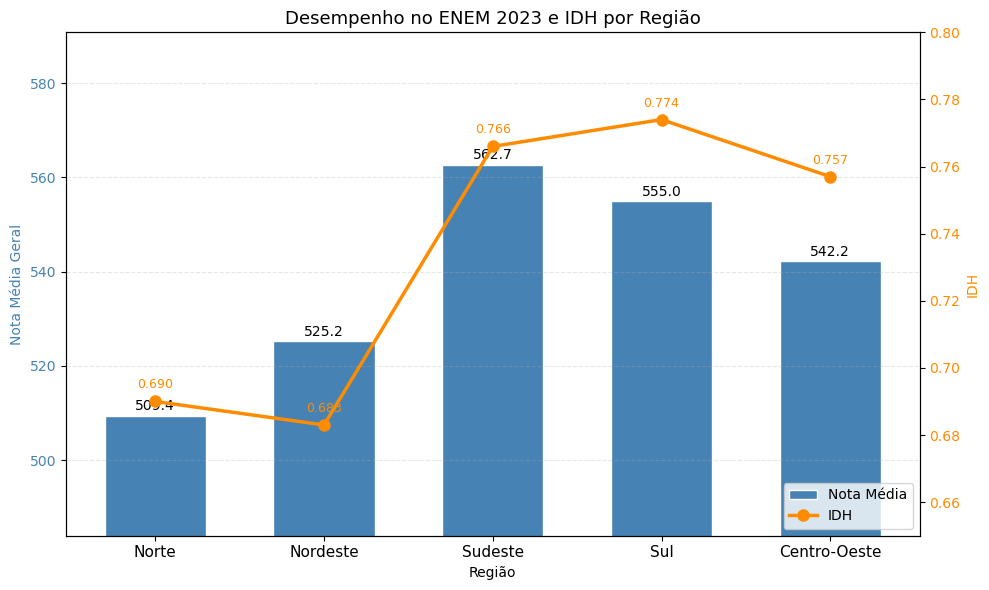

In [35]:
fig, ax1 = plt.subplots(figsize=(10, 6))

# Eixo 1 — barras de nota
bars = ax1.bar(range(len(regioes)), media_regiao,
               color="steelblue", edgecolor="white", width=0.6, label="Nota Média")

for bar, valor in zip(bars, media_regiao):
    ax1.text(bar.get_x() + bar.get_width() / 2, valor + 0.5,
             f"{valor:.1f}", ha="center", va="bottom", fontsize=10)

ax1.set_ylabel("Nota Média Geral", color="steelblue")
ax1.set_ylim(media_regiao.min() * 0.95, media_regiao.max() * 1.05)
ax1.set_xticks(range(len(regioes)))
ax1.set_xticklabels(regioes, fontsize=11)
ax1.set_xlabel("Região")
ax1.tick_params(axis="y", labelcolor="steelblue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Eixo 2 — linha de IDH
ax2 = ax1.twinx()
ax2.plot(range(len(regioes)), idh_valores, color="darkorange",
         linewidth=2.5, marker="o", markersize=8, label="IDH", zorder=3)

for i, valor in enumerate(idh_valores):
    ax2.text(i, valor + 0.003, f"{valor:.3f}",
             ha="center", va="bottom", fontsize=9, color="darkorange")

ax2.set_ylabel("IDH", color="darkorange")
ax2.set_ylim(0.65, 0.80)
ax2.tick_params(axis="y", labelcolor="darkorange")

# Legenda unificada
linhas1, labels1 = ax1.get_legend_handles_labels()
linhas2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(linhas1 + linhas2, labels1 + labels2, loc="lower right")

plt.title("Desempenho no ENEM 2023 e IDH por Região", fontsize=13)
plt.tight_layout()
plt.savefig("desempenho_idh_por_regiao.png", dpi=120, bbox_inches="tight")
plt.show()

-----------------------------------------------------------------------------------------------------------

# Microdados ENEM 2021 - Inep
- MICRODADOS_ENEM_2021.csv

In [19]:
COLUNAS_ENEM_2021 = ['NU_ANO','TP_SEXO', 'TP_COR_RACA', 'TP_ESCOLA', 'IN_TREINEIRO', 'CO_MUNICIPIO_PROVA', 'TP_PRESENCA_CN', 
                    'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT','NU_NOTA_CN', 'NU_NOTA_CH','NU_NOTA_LC',
                    'NU_NOTA_MT','NU_NOTA_REDACAO', 'TP_STATUS_REDACAO', 'Q005', 'Q006']

# Q005: Quantidade de moradores na residência.
# Q006: Renda familiar total.

df_enem2021 = pd.read_csv('MICRODADOS_ENEM_2021.csv', sep=';', encoding='latin-1', usecols=COLUNAS_ENEM_2021)

# Seleciona apenas os presentes no dia das provas
df_enem2021 = df_enem2021[(df_enem2021['TP_PRESENCA_CN'] == 1) & 
                          (df_enem2021['TP_PRESENCA_CH'] == 1) & 
                          (df_enem2021['TP_PRESENCA_LC'] == 1) & 
                          (df_enem2021['TP_PRESENCA_MT'] == 1)]

In [ ]:
df_enem2021

,NU_ANO,TP_SEXO,TP_COR_RACA,TP_ESCOLA,IN_TREINEIRO,CO_MUNICIPIO_PROVA,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q005,Q006
1,2021,M,1,1,0,2704302,1,1,1,1,505.9,551.8,498.3,461.5,1.0,560.0,3.0,B
3,2021,M,3,2,0,2304202,1,1,1,1,580.7,678.9,638.9,659.5,1.0,780.0,6.0,B
4,2021,F,3,2,0,2300150,1,1,1,1,497.7,532.4,457.6,582.6,1.0,780.0,4.0,C
8,2021,F,3,2,0,3106200,1,1,1,1,487.4,476.5,450.7,493.4,1.0,520.0,2.0,B
9,2021,F,3,2,0,2927200,1,1,1,1,507.6,539.2,494.6,413.3,1.0,380.0,2.0,B
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3389793,2021,F,1,1,0,3530706,1,1,1,1,506.0,405.2,416.3,450.4,1.0,240.0,4.0,D
3389807,2021,M,3,1,0,3167202,1,1,1,1,435.6,531.2,534.7,399.2,1.0,320.0,3.0,E
3389814,2021,M,1,1,0,3303203,1,1,1,1,576.9,605.6,631.0,678.0,1.0,640.0,3.0,B
3389815,2021,F,3,1,0,1304237,1,1,1,1,449.9,368.2,466.3,370.0,1.0,540.0,8.0,A


In [20]:
# Adicionando colunas de região e UF

REGIOES = {"1": "Norte", "2": "Nordeste", "3": "Sudeste", "4": "Sul", "5": "Centro-Oeste"}

UFS = {
    "11": "RO", "12": "AC", "13": "AM", "14": "RR", "15": "PA", "16": "AP", "17": "TO",
    "21": "MA", "22": "PI", "23": "CE", "24": "RN", "25": "PB", "26": "PE",
    "27": "AL", "28": "SE", "29": "BA",
    "31": "MG", "32": "ES", "33": "RJ", "35": "SP",
    "41": "PR", "42": "SC", "43": "RS",
    "50": "MS", "51": "MT", "52": "GO", "53": "DF"
}

df_enem2021["NO_REGIAO"] = df_enem2021["CO_MUNICIPIO_PROVA"].astype(str).str[0].map(REGIOES)
df_enem2021["SG_UF"]     = df_enem2021["CO_MUNICIPIO_PROVA"].astype(str).str[:2].map(UFS)

df_enem2021.drop('CO_MUNICIPIO_PROVA', axis=1, inplace=True)
df_enem2021

,NU_ANO,TP_SEXO,TP_COR_RACA,TP_ESCOLA,IN_TREINEIRO,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_STATUS_REDACAO,NU_NOTA_REDACAO,Q005,Q006,NO_REGIAO,SG_UF
1,2021,M,1,1,0,1,1,1,1,505.9,551.8,498.3,461.5,1.0,560.0,3.0,B,Nordeste,AL
3,2021,M,3,2,0,1,1,1,1,580.7,678.9,638.9,659.5,1.0,780.0,6.0,B,Nordeste,CE
4,2021,F,3,2,0,1,1,1,1,497.7,532.4,457.6,582.6,1.0,780.0,4.0,C,Nordeste,CE
8,2021,F,3,2,0,1,1,1,1,487.4,476.5,450.7,493.4,1.0,520.0,2.0,B,Sudeste,MG
9,2021,F,3,2,0,1,1,1,1,507.6,539.2,494.6,413.3,1.0,380.0,2.0,B,Nordeste,BA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3389793,2021,F,1,1,0,1,1,1,1,506.0,405.2,416.3,450.4,1.0,240.0,4.0,D,Sudeste,SP
3389807,2021,M,3,1,0,1,1,1,1,435.6,531.2,534.7,399.2,1.0,320.0,3.0,E,Sudeste,MG
3389814,2021,M,1,1,0,1,1,1,1,576.9,605.6,631.0,678.0,1.0,640.0,3.0,B,Sudeste,RJ
3389815,2021,F,3,1,0,1,1,1,1,449.9,368.2,466.3,370.0,1.0,540.0,8.0,A,Norte,AM


In [21]:
duplicatas = df_enem2021.duplicated().sum()
print(duplicatas)

0


In [22]:
verifica_nulos(df_enem2021)


  Total de colunas com nulos: 2 de 19
  Total de células nulas    : 2

  Coluna                              Nulos   Percentual
  ------------------------------------------------------
  Q005                                    1        0.00%
  Q006                                    1        0.00%


In [23]:
df_enem2021 = df_enem2021.dropna()

In [ ]:
df_enem2021.to_csv('ENEM_Tratado_2021.csv', index=False)

-----------------------------------------------------------------------------------------------------------

# Taxa de Rendimento Escolar - Inep
- tx_rend_brasil_regioes_ufs_2023.xlsx
- tx_rend_brasil_regioes_ufs_2021.xlsx

In [ ]:
# TAXA DE RENDIMENTO ESCOLAR 2023 e 2021

COLS_IDENTIF = ["NU_ANO_CENSO","UNIDGEO", "NO_CATEGORIA", "NO_DEPENDENCIA"]
COLS_DESEMPENHO = ["3_CAT_FUN", "3_CAT_MED"] # Taxas de abandono Ens. Fundamental e Ens. Médio

# Carrega planilhas Taxa de Rendimento Escolar 23 e 21
df_tx_rend_2023 = pd.read_excel('tx_rend_brasil_regioes_ufs_2023.xlsx', sheet_name="BRASIL_REGIOES_UFS ", header=8, na_values=["--"])
df_tx_rend_2021 = pd.read_excel('tx_rend_brasil_regioes_ufs_2021.xlsx', sheet_name="BRASIL_REGIOES_UFS ", header=8, na_values=["--"])
df_tx23 = df_tx_rend_2023[COLS_IDENTIF + COLS_DESEMPENHO].copy()
df_tx21 = df_tx_rend_2021[COLS_IDENTIF + COLS_DESEMPENHO].copy()

# Dropa campos onde UNIDGEO é nulo.
df_tx23 = df_tx23[~df_tx23['UNIDGEO'].isna()] 
df_tx21 = df_tx21[~df_tx21['UNIDGEO'].isna()] 

In [72]:
# TAXA DE ABANDONO POR REGIÃO 2023

regioes = ['Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']
tx23_regioes = df_tx23[df_tx23['UNIDGEO'].isin(regioes)]
tx23_regioes = tx23_regioes[tx23_regioes['NO_CATEGORIA'].isin(['Total'])]
tx23_regioes = tx23_regioes[tx23_regioes['NO_DEPENDENCIA'].isin(['Privada', 'Pública', 'Total'])]
tx23_regioes.drop('NO_CATEGORIA', axis=1, inplace=True)
print(tx23_regioes.shape)
tx23_regioes

(15, 5)


,NU_ANO_CENSO,UNIDGEO,NO_DEPENDENCIA,3_CAT_FUN,3_CAT_MED
18,2023,Norte,Total,1.5,2.4
30,2023,Norte,Privada,0.1,0.7
33,2023,Norte,Pública,1.6,2.6
36,2023,Nordeste,Total,1.0,3.4
48,2023,Nordeste,Privada,0.2,0.6
51,2023,Nordeste,Pública,1.1,3.7
54,2023,Sudeste,Total,0.5,3.5
66,2023,Sudeste,Privada,0.0,0.3
69,2023,Sudeste,Pública,0.6,4.0
72,2023,Sul,Total,0.3,4.0


In [73]:
# TAXA DE ABANDONO POR ESTADO 2023

regioes_excluir = ['Brasil', 'Norte', 'Nordeste', 'Sudeste', 'Sul', 'Centro-Oeste']
tx23_estados = df_tx23[~df_tx23['UNIDGEO'].isin(regioes_excluir)]
tx23_estados = tx23_estados[tx23_estados['NO_CATEGORIA'].isin(['Total'])]
tx23_estados = tx23_estados[tx23_estados['NO_DEPENDENCIA'].isin(['Privada', 'Pública', 'Total'])]
tx23_estados.drop('NO_CATEGORIA', axis=1, inplace=True)
tx23_estados

,NU_ANO_CENSO,UNIDGEO,NO_DEPENDENCIA,3_CAT_FUN,3_CAT_MED
108,2023,Rondônia,Total,0.7,3.9
120,2023,Rondônia,Privada,0.0,0.5
123,2023,Rondônia,Pública,0.8,4.2
126,2023,Acre,Total,2.5,6.1
138,2023,Acre,Privada,0.0,1.6
...,...,...,...,...,...
566,2023,Goiás,Privada,0.0,0.3
569,2023,Goiás,Pública,0.3,0.7
572,2023,Distrito Federal,Total,0.5,3.0
581,2023,Distrito Federal,Privada,0.0,0.5


In [ ]:
duplicatas = tx23_estados.duplicated().sum()
print(duplicatas)

0


In [ ]:
verifica_nulos(tx23_estados)


  Total de colunas com nulos: 0 de 5
  Total de células nulas    : 0

  Coluna                              Nulos   Percentual
  ------------------------------------------------------


In [ ]:
# TAXA DE ABANDONO POR REGIÃO 2021

tx21_regioes = df_tx21[df_tx21['UNIDGEO'].isin(regioes)]
tx21_regioes = tx21_regioes[tx21_regioes['NO_CATEGORIA'].isin(['Total'])]
tx21_regioes = tx21_regioes[tx21_regioes['NO_DEPENDENCIA'].isin(['Privada', 'Pública', 'Total'])]
tx21_regioes.drop('NO_CATEGORIA', axis=1, inplace=True)
print(tx21_regioes.shape)
tx21_regioes

(15, 5)


,NU_ANO_CENSO,UNIDGEO,NO_DEPENDENCIA,3_CAT_FUN,3_CAT_MED
18,2021,Norte,Total,2.5,10.1
30,2021,Norte,Privada,0.3,0.3
33,2021,Norte,Pública,2.6,10.7
36,2021,Nordeste,Total,1.9,6.3
48,2021,Nordeste,Privada,0.4,0.7
51,2021,Nordeste,Pública,2.2,6.8
54,2021,Sudeste,Total,0.7,3.0
66,2021,Sudeste,Privada,0.1,0.1
69,2021,Sudeste,Pública,0.9,3.5
72,2021,Sul,Total,0.8,5.7


In [ ]:
# TAXA DE ABANDONO POR ESTADO 2021

tx21_estados = df_tx21[~df_tx21['UNIDGEO'].isin(regioes_excluir)]
tx21_estados = tx21_estados[tx21_estados['NO_CATEGORIA'].isin(['Total'])]
tx21_estados = tx21_estados[tx21_estados['NO_DEPENDENCIA'].isin(['Privada', 'Pública', 'Total'])]
tx21_estados.drop('NO_CATEGORIA', axis=1, inplace=True)
tx21_estados

,NU_ANO_CENSO,UNIDGEO,NO_DEPENDENCIA,3_CAT_FUN,3_CAT_MED
108,2021,Rondônia,Total,1.1,5.0
120,2021,Rondônia,Privada,0.0,1.4
123,2021,Rondônia,Pública,1.1,5.2
126,2021,Acre,Total,2.6,6.2
137,2021,Acre,Privada,0.0,0.2
...,...,...,...,...,...
565,2021,Goiás,Privada,0.2,0.2
568,2021,Goiás,Pública,0.7,1.3
571,2021,Distrito Federal,Total,0.1,1.0
580,2021,Distrito Federal,Privada,0.0,0.0


In [ ]:
duplicatas = tx21_estados.duplicated().sum()
print(duplicatas)

0


In [ ]:
verifica_nulos(tx21_estados)


  Total de colunas com nulos: 0 de 5
  Total de células nulas    : 0

  Coluna                              Nulos   Percentual
  ------------------------------------------------------


In [ ]:
tx21_regioes.to_csv('Taxa_Abandono_REGIAO_2021.csv', index=False)
tx21_estados.to_csv('Taxa_Abandono_ESTADO_2021.csv', index=False)

In [ ]:
tx23_regioes.to_csv('Taxa_Abandono_REGIAO_2023.csv', index=False)
tx23_estados.to_csv('Taxa_Abandono_ESTADO_2023.csv', index=False)

-----------------------------------------------------------------------------------------------------------

# Microdados SAEB 2023 - Inep

- TS_ALUNO_34EM.csv
- TS_ITEM.csv

In [ ]:
COLUNAS_SAEB_34EM = ['ID_REGIAO', 'ID_UF', 'IN_PUBLICA', 'INSE_ALUNO', 'NU_TIPO_NIVEL_INSE', 'ID_LOCALIZACAO', 'ID_SERIE',
                     'ID_BLOCO_1_LP', 'ID_BLOCO_2_LP', 'ID_BLOCO_1_MT', 'ID_BLOCO_2_MT', 'TX_RESP_BLOCO1_LP', 'TX_RESP_BLOCO2_LP', 
                     'TX_RESP_BLOCO1_MT', 'TX_RESP_BLOCO2_MT', 'IN_PREENCHIMENTO_LP', 'IN_PREENCHIMENTO_MT']

df_aluno_34EM = pd.read_csv('TS_ALUNO_34EM_2023.csv', sep=';', encoding='latin-1', usecols=COLUNAS_SAEB_34EM)
df_aluno_34EM = df_aluno_34EM[(df_aluno_34EM['IN_PREENCHIMENTO_LP'] == 1) & (df_aluno_34EM['IN_PREENCHIMENTO_MT'] == 1)]

df_aluno_34EM.drop('IN_PREENCHIMENTO_LP', axis=1, inplace=True)
df_aluno_34EM.drop('IN_PREENCHIMENTO_MT', axis=1, inplace=True)

In [ ]:
dp = df_aluno_34EM.duplicated().sum()
print(dp)

5


In [ ]:
df_aluno_34EM = df_aluno_34EM.drop_duplicates()

In [ ]:
# Valores nulos SAEB 2023

verifica_nulos(df_aluno_34EM)


  Total de colunas com nulos: 1 de 15
  Total de células nulas    : 93,556

  Coluna                              Nulos   Percentual
  ------------------------------------------------------
  INSE_ALUNO                         93,556        6.14%


In [ ]:
nulos_mask = df_aluno_34EM["INSE_ALUNO"].isnull()

# Distribuição dos nulos por região
print(df_aluno_34EM[nulos_mask]["ID_REGIAO"].value_counts(normalize=True))

# Distribuição dos nulos por UF
print(df_aluno_34EM[nulos_mask]["ID_UF"].value_counts())

# Distribuição dos nulos por tipo de escola
print(df_aluno_34EM[nulos_mask]["IN_PUBLICA"].value_counts(normalize=True))

ID_REGIAO
3    0.404827
2    0.311354
4    0.120847
1    0.085671
5    0.077301
Name: proportion, dtype: float64
ID_UF
35    20975
31     8872
26     7145
33     6080
29     5738
23     5149
43     4843
21     3969
41     3891
52     3058
42     2572
15     2516
13     2491
25     2404
32     1947
53     1696
22     1550
51     1318
27     1211
50     1160
24     1143
11      958
28      820
17      793
16      453
12      409
14      395
Name: count, dtype: int64
IN_PUBLICA
1    0.981904
0    0.018096
Name: proportion, dtype: float64


In [ ]:
# Imputar nulos pela mediana de INSE de alunos da mesma UF e mesmo tipo de escola

df_aluno_34EM["INSE_ALUNO"] = df_aluno_34EM.groupby(["ID_UF", "IN_PUBLICA"])["INSE_ALUNO"].transform(
    lambda x: x.fillna(x.median())
)

In [ ]:
# Corrindo Categoria INSE

# Nivel 1
df_aluno_34EM['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM['INSE_ALUNO'] < 3.0), 
    1, 
    df_aluno_34EM['NU_TIPO_NIVEL_INSE']
)

# Nivel 2
df_aluno_34EM['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM['INSE_ALUNO'] >= 3.0) & (df_aluno_34EM['INSE_ALUNO'] < 4.0), 
    2, 
    df_aluno_34EM['NU_TIPO_NIVEL_INSE']
)

# Nivel 3
df_aluno_34EM['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM['INSE_ALUNO'] >= 4.0) & (df_aluno_34EM['INSE_ALUNO'] < 4.5), 
    3, 
    df_aluno_34EM['NU_TIPO_NIVEL_INSE']
)

# Nivel 4
df_aluno_34EM['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM['INSE_ALUNO'] >= 4.50) & (df_aluno_34EM['INSE_ALUNO'] < 5.0), 
    4, 
    df_aluno_34EM['NU_TIPO_NIVEL_INSE']
)

# Nivel 5
df_aluno_34EM['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM['INSE_ALUNO'] >= 5.0) & (df_aluno_34EM['INSE_ALUNO'] < 5.5), 
    5, 
    df_aluno_34EM['NU_TIPO_NIVEL_INSE']
)

# Nivel 6
df_aluno_34EM['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM['INSE_ALUNO'] >= 5.5) & (df_aluno_34EM['INSE_ALUNO'] < 6.0), 
    6, 
    df_aluno_34EM['NU_TIPO_NIVEL_INSE']
)

# Nivel 7
df_aluno_34EM['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM['INSE_ALUNO'] >= 6.0) & (df_aluno_34EM['INSE_ALUNO'] < 7.0), 
    7, 
    df_aluno_34EM['NU_TIPO_NIVEL_INSE']
)

# Nivel 8
df_aluno_34EM['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM['INSE_ALUNO'] >= 7.0), 
    8, 
    df_aluno_34EM['NU_TIPO_NIVEL_INSE']
)

In [ ]:
verifica_nulos(df_aluno_34EM)


  Total de colunas com nulos: 0 de 15
  Total de células nulas    : 0

  Coluna                              Nulos   Percentual
  ------------------------------------------------------


In [ ]:
df_aluno_34EM

,ID_REGIAO,ID_UF,IN_PUBLICA,ID_LOCALIZACAO,ID_SERIE,ID_BLOCO_1_LP,ID_BLOCO_2_LP,ID_BLOCO_1_MT,ID_BLOCO_2_MT,TX_RESP_BLOCO1_LP,TX_RESP_BLOCO2_LP,TX_RESP_BLOCO1_MT,TX_RESP_BLOCO2_MT,INSE_ALUNO,NU_TIPO_NIVEL_INSE
0,1,11,1,1,12,7,1,7,1,ADCDADDADBBCC,ADEADAADDCCDD,BCACECDDDDBEA,DDCABBABCBDDB,4.36,3.0
1,1,11,1,1,12,2,4,2,4,ABADAEABAACAB,ABAEBABAAEABA,BCAABECAACEBB,CBCAEAABBCAAB,3.43,2.0
2,1,11,1,1,12,4,6,4,6,DDACEBCAABABD,DCAACAAABCAAC,DDBCCCBDABDCA,ECDDEDACDEADA,5.60,6.0
3,1,11,1,1,12,1,2,1,2,AEDCAEBCDABDB,CADBEABDBDABA,BADACDAACCABE,BAEBAABDCADEB,5.23,5.0
4,1,11,1,1,12,4,5,4,5,BEBEECABACADB,EBABAEACBCADD,DDEBEBACBDAED,BCDBCABCDBCCC,4.83,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2091328,5,53,1,1,12,6,2,6,2,CBEACBDBDBEAE,EECCCDABADACB,BCCEBABBBAEAB,ACDDBCACCBABD,4.11,3.0
2091329,5,53,1,1,12,7,3,7,3,CDAAABBCBAECD,BDBEDBDCBAABD,DCEDECCBDDBAA,ADABCDCBDEABE,5.33,5.0
2091330,5,53,1,1,12,2,4,2,4,ECACCADCBCCBB,BABEDECADCAED,AEDEDDDCCEECD,CAEABDADDEABC,5.49,5.0
2091331,5,53,1,1,12,3,5,3,5,DBAEDBACBBAEB,EAACDCCACBACA,CAEBCDCACAEBA,BBDACABCBABDA,5.33,5.0


In [ ]:
# Carregando arquivo de gabarito das provas 

COLUNAS_ITEM_SAEB = ['ID_SERIE','TP_DISCIPLINA','NU_BLOCO','NU_POSICAO','ID_ITEM','TX_GABARITO']

df_item = pd.read_csv('TS_ITEM_2023.csv', sep=';', encoding='latin-1', usecols=COLUNAS_ITEM_SAEB)

df_item_34EM = df_item[df_item['ID_SERIE'] == 3]

In [ ]:
# Gabarito SAEB LP
df_item_LP = df_item_34EM[df_item_34EM['TP_DISCIPLINA'] == 'LP']
gabarito_LP = df_item_LP.groupby('NU_BLOCO')['TX_GABARITO'].apply(list).reset_index()
print(gabarito_LP)

   NU_BLOCO                              TX_GABARITO
0         1  [A, E, D, C, D, C, C, A, C, E, C, B, C]
1         2  [E, E, A, E, C, A, D, C, B, X, C, B, B]
2         3  [B, D, B, E, D, B, D, C, B, C, A, B, C]
3         4  [B, A, B, E, D, E, C, A, D, C, A, E, D]
4         5  [E, A, B, C, A, C, D, B, C, D, E, C, A]
5         6  [E, B, E, B, C, C, D, B, D, B, E, X, A]
6         7  [C, D, A, A, A, B, B, D, B, A, E, C, D]


In [ ]:
# Gabarito SAEB MT
df_item_MT = df_item_34EM[df_item_34EM['TP_DISCIPLINA'] == 'MT']
gabarito_MT = df_item_MT.groupby('NU_BLOCO')['TX_GABARITO'].apply(list).reset_index()
print(gabarito_MT)

   NU_BLOCO                              TX_GABARITO
0         1  [C, E, C, D, B, D, D, B, A, A, A, E, B]
1         2  [A, B, D, E, B, D, B, C, C, B, E, D, A]
2         3  [A, E, B, D, C, A, C, B, D, B, A, E, D]
3         4  [C, D, B, A, D, E, A, D, B, E, B, C, A]
4         5  [D, C, D, E, C, A, A, B, A, C, D, A, B]
5         6  [X, C, C, E, A, E, D, C, B, E, A, E, B]
6         7  [E, D, B, B, E, C, D, B, C, C, A, D, A]


In [ ]:
# CALCULAR DESEMPENHO POR ALUNO

gab_LP = (
    gabarito_LP
    .set_index("NU_BLOCO")["TX_GABARITO"]
    .apply("".join)
    .to_dict()
)

gab_MT = (
    gabarito_MT
    .set_index("NU_BLOCO")["TX_GABARITO"]
    .apply("".join)
    .to_dict()
)

def acertos_bloco(df, col_bloco, col_resp, gab_dict):
    """
    Compara as respostas de um bloco com o gabarito correspondente.
    Retorna uma Series com a contagem de acertos por aluno.
    """
    # Mapeia o número do bloco de cada aluno para a string de gabarito
    gabarito_aluno = df[col_bloco].map(gab_dict).fillna("")
    respostas      = df[col_resp].fillna("")

    # Comprimento máximo (número de itens no bloco)
    max_itens = gabarito_aluno.str.len().max()

    acertos = pd.Series(0, index=df.index)

    # Compara posição por posição de forma vetorizada
    for i in range(int(max_itens)):
        resp_i = respostas.str[i].fillna("")
        gab_i  = gabarito_aluno.str[i].fillna("")
        # Conta acerto apenas onde ambos estão preenchidos
        acertos += (resp_i == gab_i) & (resp_i != "") & (gab_i != "")

    return acertos

df_aluno_34EM["ACERTOS_LP"] = (
    acertos_bloco(df_aluno_34EM, "ID_BLOCO_1_LP", "TX_RESP_BLOCO1_LP", gab_LP) +
    acertos_bloco(df_aluno_34EM, "ID_BLOCO_2_LP", "TX_RESP_BLOCO2_LP", gab_LP)
)

df_aluno_34EM["ACERTOS_MT"] = (
    acertos_bloco(df_aluno_34EM, "ID_BLOCO_1_MT", "TX_RESP_BLOCO1_MT", gab_MT) +
    acertos_bloco(df_aluno_34EM, "ID_BLOCO_2_MT", "TX_RESP_BLOCO2_MT", gab_MT)
)

In [ ]:
df_aluno_34EM["ACERTOS_TOTAIS"] = df_aluno_34EM["ACERTOS_LP"] + df_aluno_34EM["ACERTOS_MT"]
df_aluno_34EM

,ID_REGIAO,ID_UF,IN_PUBLICA,ID_LOCALIZACAO,ID_SERIE,ID_BLOCO_1_LP,ID_BLOCO_2_LP,ID_BLOCO_1_MT,ID_BLOCO_2_MT,TX_RESP_BLOCO1_LP,TX_RESP_BLOCO2_LP,TX_RESP_BLOCO1_MT,TX_RESP_BLOCO2_MT,INSE_ALUNO,NU_TIPO_NIVEL_INSE,ACERTOS_LP,ACERTOS_MT,ACERTOS_TOTAIS
0,1,11,1,1,12,7,1,7,1,ADCDADDADBBCC,ADEADAADDCCDD,BCACECDDDDBEA,DDCABBABCBDDB,4.36,3.0,6,8,14
1,1,11,1,1,12,2,4,2,4,ABADAEABAACAB,ABAEBABAAEABA,BCAABECAACEBB,CBCAEAABBCAAB,3.43,2.0,6,6,12
2,1,11,1,1,12,4,6,4,6,DDACEBCAABABD,DCAACAAABCAAC,DDBCCCBDABDCA,ECDDEDACDEADA,5.60,6.0,5,9,14
3,1,11,1,1,12,1,2,1,2,AEDCAEBCDABDB,CADBEABDBDABA,BADACDAACCABE,BAEBAABDCADEB,5.23,5.0,7,4,11
4,1,11,1,1,12,4,5,4,5,BEBEECABACADB,EBABAEACBCADD,DDEBEBACBDAED,BCDBCABCDBCCC,4.83,4.0,7,7,14
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2091328,5,53,1,1,12,6,2,6,2,CBEACBDBDBEAE,EECCCDABADACB,BCCEBABBBAEAB,ACDDBCACCBABD,4.11,3.0,12,11,23
2091329,5,53,1,1,12,7,3,7,3,CDAAABBCBAECD,BDBEDBDCBAABD,DCEDECCBDDBAA,ADABCDCBDEABE,5.33,5.0,23,10,33
2091330,5,53,1,1,12,2,4,2,4,ECACCADCBCCBB,BABEDECADCAED,AEDEDDDCCEECD,CAEABDADDEABC,5.49,5.0,23,12,35
2091331,5,53,1,1,12,3,5,3,5,DBAEDBACBBAEB,EAACDCCACBACA,CAEBCDCACAEBA,BBDACABCBABDA,5.33,5.0,13,5,18


In [ ]:
df_aluno_34EM.to_csv('SAEB_Tratado_2023.csv', index=False)

-----------------------------------------------------------------------------------------------------------

# Microdados SAEB 2021 - Inep

- TS_ALUNO_34EM.csv
- TS_ITEM.csv

In [60]:
COLUNAS_SAEB_34EM = ['ID_REGIAO', 'ID_UF', 'IN_PUBLICA', 'INSE_ALUNO', 'NU_TIPO_NIVEL_INSE', 'ID_LOCALIZACAO', 'ID_SERIE',
                     'ID_BLOCO_1_LP', 'ID_BLOCO_2_LP', 'ID_BLOCO_1_MT', 'ID_BLOCO_2_MT', 'TX_RESP_BLOCO1_LP', 'TX_RESP_BLOCO2_LP', 
                     'TX_RESP_BLOCO1_MT', 'TX_RESP_BLOCO2_MT', 'IN_PREENCHIMENTO_LP', 'IN_PREENCHIMENTO_MT']

df_aluno_34EM_21 = pd.read_csv('TS_ALUNO_34EM_2021.csv', sep=';', encoding='latin-1', usecols=COLUNAS_SAEB_34EM)
df_aluno_34EM_21 = df_aluno_34EM_21[(df_aluno_34EM_21['IN_PREENCHIMENTO_LP'] == 1) & (df_aluno_34EM_21['IN_PREENCHIMENTO_MT'] == 1)]

df_aluno_34EM_21.drop('IN_PREENCHIMENTO_LP', axis=1, inplace=True)
df_aluno_34EM_21.drop('IN_PREENCHIMENTO_MT', axis=1, inplace=True)

In [ ]:
df_aluno_34EM = df_aluno_34EM_21.drop_duplicates()

,ID_REGIAO,ID_UF,IN_PUBLICA,ID_LOCALIZACAO,ID_SERIE,ID_BLOCO_1_LP,ID_BLOCO_2_LP,ID_BLOCO_1_MT,ID_BLOCO_2_MT,TX_RESP_BLOCO1_LP,TX_RESP_BLOCO2_LP,TX_RESP_BLOCO1_MT,TX_RESP_BLOCO2_MT,INSE_ALUNO,NU_TIPO_NIVEL_INSE
0,1,11,1,1,12,3,6,3,6,DDECAACCBAEEA,BDDBCBBADDEEB,AACAAAAAADEEE,CCECCEACBDEAC,4.73,4.0
3,1,11,1,1,12,2,5,2,5,DAAABDAACAEBA,ADEEBCCADECAA,DACEDBDACCABA,CEEECCDAAABDB,4.81,4.0
4,1,11,1,1,12,1,2,1,2,EDBDEEBACBCAD,AAACCBACBEECA,EBDDBDBDBDCCA,DADEDBDAACACB,5.32,5.0
5,1,11,1,1,12,2,3,2,3,DEAABDAACDEBA,EDEEBADBAAEAA,DCCEDCDACDBCA,ADBAEEBADAADE,4.72,4.0
6,1,11,1,1,12,4,7,4,7,BECEECCACCECA,DEEEBBADACCBA,CBBADBCADBACA,ACAAABCBCAEAE,4.60,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288485,5,53,1,1,12,4,6,4,6,BBBCECCADACED,DDDCACBDAECAB,CBAEDBCABCAAD,CDECDBACBCAEB,5.36,5.0
2288487,5,53,1,1,12,2,4,2,4,DDAACDACCEEBA,BCCEEBCACBCCC,DBBAADBAACADC,CBADDBCABDBAC,5.02,5.0
2288729,5,53,0,1,12,4,6,4,6,ACCBEDCDADBEE,BBDACECAACCCB,CBEDDDCADEEBC,DEEEDEDABAAAB,7.62,8.0
2288733,5,53,0,1,12,4,5,4,5,BECEECCACBBCA,ABEEBCCBDECAA,CBDADBCADEECC,CEDEDEDAAABBB,6.58,7.0


In [62]:
verifica_nulos(df_aluno_34EM_21)


  Total de colunas com nulos: 2 de 15
  Total de células nulas    : 114,204

  Coluna                              Nulos   Percentual
  ------------------------------------------------------
  INSE_ALUNO                         57,102        4.08%
  NU_TIPO_NIVEL_INSE                 57,102        4.08%


In [63]:
nulos_mask = df_aluno_34EM_21["INSE_ALUNO"].isnull()

# Distribuição dos nulos por região
print(df_aluno_34EM_21[nulos_mask]["ID_REGIAO"].value_counts(normalize=True))

# Distribuição dos nulos por UF
print(df_aluno_34EM_21[nulos_mask]["ID_UF"].value_counts())

# Distribuição dos nulos por tipo de escola
print(df_aluno_34EM_21[nulos_mask]["IN_PUBLICA"].value_counts(normalize=True))

ID_REGIAO
3    0.368201
2    0.300690
4    0.177997
1    0.097667
5    0.055445
Name: proportion, dtype: float64
ID_UF
35    10969
41     8668
29     5518
31     4938
33     4772
26     3674
23     2947
13     2749
21     2366
15     1930
52     1759
43      989
27      981
51      701
22      519
24      514
42      507
25      461
53      380
32      346
50      326
12      285
17      224
11      192
28      190
16      130
14       67
Name: count, dtype: int64
IN_PUBLICA
1    0.993083
0    0.006917
Name: proportion, dtype: float64


In [64]:
# Imputar nulos pela mediana de INSE de alunos da mesma UF e mesmo tipo de escola

df_aluno_34EM_21["INSE_ALUNO"] = df_aluno_34EM_21.groupby(["ID_UF", "IN_PUBLICA"])["INSE_ALUNO"].transform(
    lambda x: x.fillna(x.median())
)

In [65]:
# Imputando nulos em NU_TIPO_NIVEL_INSE 

# Nivel 1
df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM_21['INSE_ALUNO'] < 3.0) & (df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'].isna()), 
    1.0, 
    df_aluno_34EM_21['NU_TIPO_NIVEL_INSE']
)

# Nivel 2
df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM_21['INSE_ALUNO'] >= 3.0) & (df_aluno_34EM_21['INSE_ALUNO'] < 4.0) & (df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'].isna()), 
    2.0, 
    df_aluno_34EM_21['NU_TIPO_NIVEL_INSE']
)

# Nivel 3
df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM_21['INSE_ALUNO'] >= 4.0) & (df_aluno_34EM_21['INSE_ALUNO'] < 4.5) & (df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'].isna()), 
    3.0, 
    df_aluno_34EM_21['NU_TIPO_NIVEL_INSE']
)

# Nivel 4
df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM_21['INSE_ALUNO'] >= 4.50) & (df_aluno_34EM_21['INSE_ALUNO'] < 5.0) & (df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'].isna()), 
    4.0, 
    df_aluno_34EM_21['NU_TIPO_NIVEL_INSE']
)

# Nivel 5
df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM_21['INSE_ALUNO'] >= 5.0) & (df_aluno_34EM_21['INSE_ALUNO'] < 5.5) & (df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'].isna()), 
    5.0, 
    df_aluno_34EM_21['NU_TIPO_NIVEL_INSE']
)

# Nivel 6
df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM_21['INSE_ALUNO'] >= 5.5) & (df_aluno_34EM_21['INSE_ALUNO'] < 6.0) & (df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'].isna()), 
    6.0, 
    df_aluno_34EM_21['NU_TIPO_NIVEL_INSE']
)

# Nivel 7
df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM_21['INSE_ALUNO'] >= 6.0) & (df_aluno_34EM_21['INSE_ALUNO'] < 7.0) & (df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'].isna()), 
    7.0, 
    df_aluno_34EM_21['NU_TIPO_NIVEL_INSE']
)

# Nivel 8
df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'] = np.where(
    (df_aluno_34EM_21['INSE_ALUNO'] >= 7.0) & (df_aluno_34EM_21['NU_TIPO_NIVEL_INSE'].isna()), 
    8.0, 
    df_aluno_34EM_21['NU_TIPO_NIVEL_INSE']
)

In [66]:
df_aluno_34EM_21

,ID_REGIAO,ID_UF,IN_PUBLICA,ID_LOCALIZACAO,ID_SERIE,ID_BLOCO_1_LP,ID_BLOCO_2_LP,ID_BLOCO_1_MT,ID_BLOCO_2_MT,TX_RESP_BLOCO1_LP,TX_RESP_BLOCO2_LP,TX_RESP_BLOCO1_MT,TX_RESP_BLOCO2_MT,INSE_ALUNO,NU_TIPO_NIVEL_INSE
0,1,11,1,1,12,3,6,3,6,DDECAACCBAEEA,BDDBCBBADDEEB,AACAAAAAADEEE,CCECCEACBDEAC,4.73,4.0
3,1,11,1,1,12,2,5,2,5,DAAABDAACAEBA,ADEEBCCADECAA,DACEDBDACCABA,CEEECCDAAABDB,4.81,4.0
4,1,11,1,1,12,1,2,1,2,EDBDEEBACBCAD,AAACCBACBEECA,EBDDBDBDBDCCA,DADEDBDAACACB,5.32,5.0
5,1,11,1,1,12,2,3,2,3,DEAABDAACDEBA,EDEEBADBAAEAA,DCCEDCDACDBCA,ADBAEEBADAADE,4.72,4.0
6,1,11,1,1,12,4,7,4,7,BECEECCACCECA,DEEEBBADACCBA,CBBADBCADBACA,ACAAABCBCAEAE,4.60,4.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288485,5,53,1,1,12,4,6,4,6,BBBCECCADACED,DDDCACBDAECAB,CBAEDBCABCAAD,CDECDBACBCAEB,5.36,5.0
2288487,5,53,1,1,12,2,4,2,4,DDAACDACCEEBA,BCCEEBCACBCCC,DBBAADBAACADC,CBADDBCABDBAC,5.02,5.0
2288729,5,53,0,1,12,4,6,4,6,ACCBEDCDADBEE,BBDACECAACCCB,CBEDDDCADEEBC,DEEEDEDABAAAB,7.62,8.0
2288733,5,53,0,1,12,4,5,4,5,BECEECCACBBCA,ABEEBCCBDECAA,CBDADBCADEECC,CEDEDEDAAABBB,6.58,7.0


In [67]:
verifica_nulos(df_aluno_34EM_21)


  Total de colunas com nulos: 0 de 15
  Total de células nulas    : 0

  Coluna                              Nulos   Percentual
  ------------------------------------------------------


In [53]:
# Carregando arquivo de gabarito das provas 

COLUNAS_ITEM_SAEB = ['ID_SERIE','DISCIPLINA','BLOCO','POSICAO','ID_ITEM','GABARITO']

df_item_21 = pd.read_csv('TS_ITEM_2021.csv', sep=';', encoding='latin-1', usecols=COLUNAS_ITEM_SAEB)

df_item_34EM_21 = df_item_21[df_item_21['ID_SERIE'] == 12]

In [56]:
# Gabarito SAEB 21 LP
df_item_LP_21 = df_item_34EM_21[df_item_34EM_21['DISCIPLINA'] == 'LP']
gabarito_LP_21 = df_item_LP_21.groupby('BLOCO')['GABARITO'].apply(list).reset_index()
print(gabarito_LP_21)

   BLOCO                                 GABARITO
0      1  [E, X, B, D, B, D, A, C, C, B, C, X, C]
1      2  [D, A, A, A, B, D, A, A, C, C, E, B, A]
2      3  [E, D, E, E, B, A, D, B, B, A, E, A, A]
3      4  [B, E, C, E, E, C, C, A, C, E, X, C, A]
4      5  [A, D, E, E, B, C, C, B, D, E, C, A, A]
5      6  [C, D, D, B, E, A, B, X, A, A, D, B, B]
6      7  [D, E, E, E, C, B, A, D, A, C, C, D, E]


In [58]:
# Gabarito SAEB 21 MT
df_item_MT_21 = df_item_34EM_21[df_item_34EM_21['DISCIPLINA'] == 'MT']
gabarito_MT_21 = df_item_MT_21.groupby('BLOCO')['GABARITO'].apply(list).reset_index()
print(gabarito_MT_21)

   BLOCO                                 GABARITO
0      1  [E, B, C, D, C, D, B, D, A, C, D, C, A]
1      2  [D, A, C, E, D, B, D, A, C, C, B, C, A]
2      3  [A, C, B, A, E, C, A, A, A, C, D, B, E]
3      4  [C, B, A, A, D, B, C, A, D, E, C, D, B]
4      5  [C, E, D, E, D, E, D, A, A, B, B, D, B]
5      6  [C, D, D, C, A, B, A, C, B, A, C, E, B]
6      7  [A, D, B, A, A, B, C, B, B, B, D, D, E]


In [69]:
# CALCULAR DESEMPENHO POR ALUNO 2021

gab_LP_21 = (
    gabarito_LP_21
    .set_index("BLOCO")["GABARITO"]
    .apply("".join)
    .to_dict()
)

gab_MT_21 = (
    gabarito_MT_21
    .set_index("BLOCO")["GABARITO"]
    .apply("".join)
    .to_dict()
)

df_aluno_34EM_21["ACERTOS_LP"] = (
    acertos_bloco(df_aluno_34EM_21, "ID_BLOCO_1_LP", "TX_RESP_BLOCO1_LP", gab_LP_21) +
    acertos_bloco(df_aluno_34EM_21, "ID_BLOCO_2_LP", "TX_RESP_BLOCO2_LP", gab_LP_21)
)

df_aluno_34EM_21["ACERTOS_MT"] = (
    acertos_bloco(df_aluno_34EM_21, "ID_BLOCO_1_MT", "TX_RESP_BLOCO1_MT", gab_MT_21) +
    acertos_bloco(df_aluno_34EM_21, "ID_BLOCO_2_MT", "TX_RESP_BLOCO2_MT", gab_MT_21)
)

df_aluno_34EM_21["ACERTOS_TOTAIS"] = df_aluno_34EM_21["ACERTOS_LP"] + df_aluno_34EM_21["ACERTOS_MT"]

In [70]:
df_aluno_34EM_21

,ID_REGIAO,ID_UF,IN_PUBLICA,ID_LOCALIZACAO,ID_SERIE,ID_BLOCO_1_LP,ID_BLOCO_2_LP,ID_BLOCO_1_MT,ID_BLOCO_2_MT,TX_RESP_BLOCO1_LP,TX_RESP_BLOCO2_LP,TX_RESP_BLOCO1_MT,TX_RESP_BLOCO2_MT,INSE_ALUNO,NU_TIPO_NIVEL_INSE,ACERTOS_LP,ACERTOS_MT,ACERTOS_TOTAIS
0,1,11,1,1,12,3,6,3,6,DDECAACCBAEEA,BDDBCBBADDEEB,AACAAAAAADEEE,CCECCEACBDEAC,4.73,4.0,12,11,23
3,1,11,1,1,12,2,5,2,5,DAAABDAACAEBA,ADEEBCCADECAA,DACEDBDACCABA,CEEECCDAAABDB,4.81,4.0,24,20,44
4,1,11,1,1,12,1,2,1,2,EDBDEEBACBCAD,AAACCBACBEECA,EBDDBDBDBDCCA,DADEDBDAACACB,5.32,5.0,11,17,28
5,1,11,1,1,12,2,3,2,3,DEAABDAACDEBA,EDEEBADBAAEAA,DCCEDCDACDBCA,ADBAEEBADAADE,4.72,4.0,23,16,39
6,1,11,1,1,12,4,7,4,7,BECEECCACCECA,DEEEBBADACCBA,CBBADBCADBACA,ACAAABCBCAEAE,4.60,4.0,21,15,36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2288485,5,53,1,1,12,4,6,4,6,BBBCECCADACED,DDDCACBDAECAB,CBAEDBCABCAAD,CDECDBACBCAEB,5.36,5.0,10,16,26
2288487,5,53,1,1,12,2,4,2,4,DDAACDACCEEBA,BCCEEBCACBCCC,DBBAADBAACADC,CBADDBCABDBAC,5.02,5.0,17,10,27
2288729,5,53,0,1,12,4,6,4,6,ACCBEDCDADBEE,BBDACECAACCCB,CBEDDDCADEEBC,DEEEDEDABAAAB,7.62,8.0,6,10,16
2288733,5,53,0,1,12,4,5,4,5,BECEECCACBBCA,ABEEBCCBDECAA,CBDADBCADEECC,CEDEDEDAAABBB,6.58,7.0,23,20,43


In [ ]:
df_aluno_34EM_21.to_csv('SAEB_Tratado_2021.csv', index=False)